# IN5340/IN9340 Project IV: Spectral estimation

The exercises in this project will be related to sonar data collected by the HUGIN autonomous underwater vehicle. Figure 1 shows the recorded sonar data after pulse compression (matched filtering) and beamforming (by delay-and-sum). The range profile
from each ping has been rotated and georeferenced relative to each other. This is called
a sidescan sonar image. The yellow lines indicates the particular ping to be used in this
exercise.
The sonar geometry is shown in Figure 2. We will consider a single ping (or pulse) with
recorded timeseries from one horisontal receiver array with Nh = 32 hydrophones (receivers).
1
Figure 2: Sonar geometry
The data file sonardata4.mat at the course web page, is a matlab mat-file that contains
the recorded timeseries from a single ping of sonar data as described above. The variable data contains a complex matrix of size [Nt
, Nh], where Nh = 32 is the number of
hydrophones, and Nt
is the number of time samples. The sampling frequency is stored
in variable fs (in Hertz). The start time for the recordings is zero.
The transmitted signal is a Linear Frequency Modulated (LFM) pulse of pulse length Tp,
with signal bandwidth of B, as follows
sT x(t) = 
exp(j2παt2/2) −Tp/2 ≤ t ≤ Tp/2
0 |t| > Tp/2
(1)
where α is the chirp rate related to the signal bandwidth as
α = B/Tp (2)
The programmed signal bandwidth was B = 30 kHz, and the center frequency of the
signal was fc = 100 kHz. Note that the received timeseries are basebanded at reception
(the carrier frequency has been removed). We have therefore taken out the carrier (center
frequency) from the signal model.


## 1 Spectral Estimation
### Exercise 1 A
Create an array out of the following selection:
• Channel 14
• Start sample M = 1200
• Number of samples N = 1024

(10000, 32)


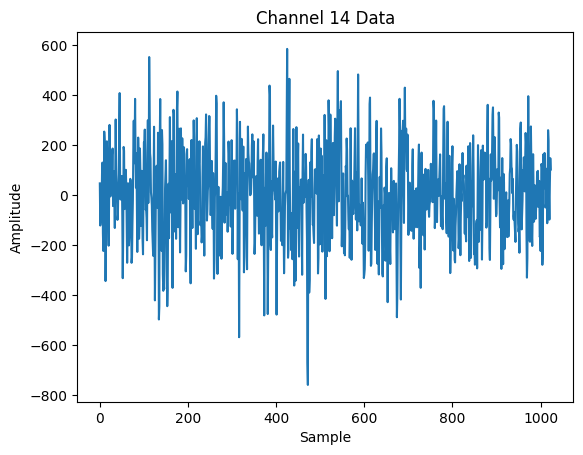

In [11]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import windows

data = scipy.io.loadmat('sonardata4.mat')
X = data['data']
B = 30000
fs = 40000
fc = 100000
T_p = 0.0035

print(X.shape)

channel_14_data = X[1200:2224, 13]

plt.plot(channel_14_data)
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.title('Channel 14 Data')
plt.show()

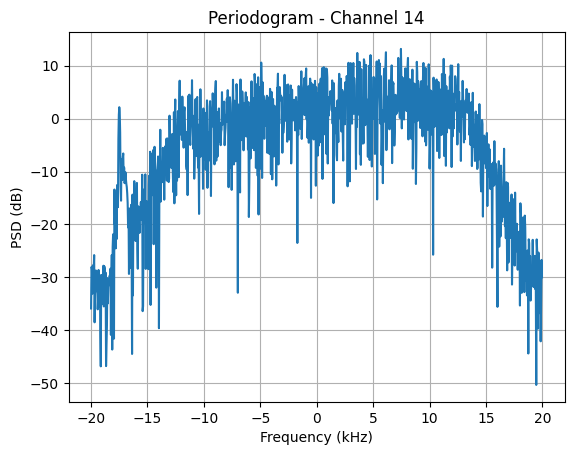

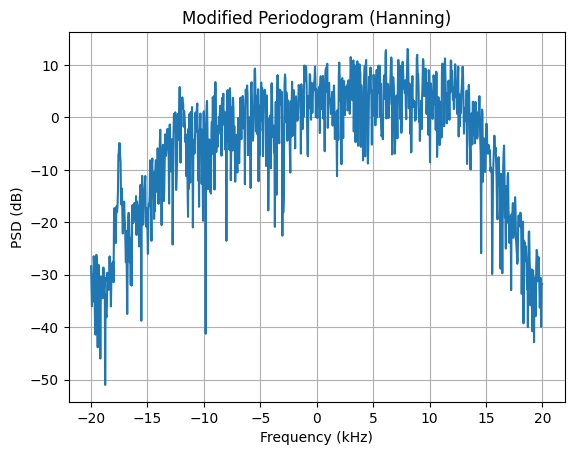

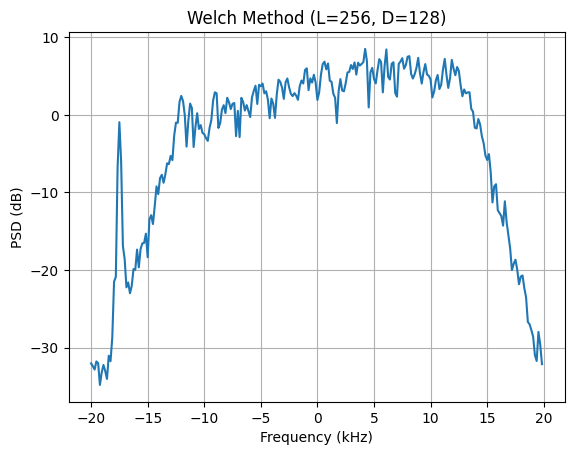

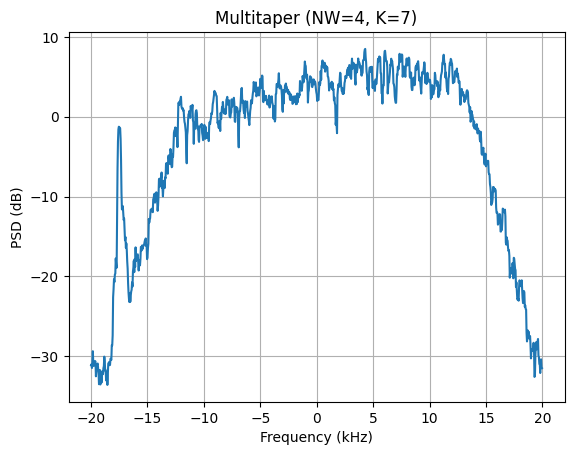

In [12]:
N = len(channel_14_data)
freqs = np.fft.fftfreq(N, d=1/fs)
freq_shifted = np.fft.fftshift(freqs)/1000

# periodogram
fft_result = np.fft.fft(channel_14_data)
periodogram = (1/(N*fs)) * np.abs(fft_result)**2
periodogram_shifted = np.fft.fftshift(periodogram)

plt.figure()
plt.plot(freq_shifted, 10*np.log10(periodogram_shifted))
plt.xlabel('Frequency (kHz)')
plt.ylabel('PSD (dB)')
plt.title('Periodogram - Channel 14')
plt.grid()
plt.show()

# modified periodogram with hanning window
win = np.hanning(N)
U = np.mean(win**2)
windowed = channel_14_data * win
fft_win = np.fft.fft(windowed)
periodogram_windowed = (1/(N*fs*U)) * np.abs(fft_win)**2
periodogram_windowed_shifted = np.fft.fftshift(periodogram_windowed)

plt.figure()
plt.plot(freq_shifted, 10*np.log10(periodogram_windowed_shifted))
plt.xlabel('Frequency (kHz)')
plt.ylabel('PSD (dB)')
plt.title('Modified Periodogram (Hanning)')
plt.grid()
plt.show()

# welch method
L = 256
D = L//2
num_segments = (N - D)//(L - D)
welch_win = np.hanning(L)
U_welch = np.mean(welch_win**2)
freq_welch = np.fft.fftshift(np.fft.fftfreq(L, d=1/fs))/1000

welch_psd = np.zeros(L)
for i in range(num_segments):
    start = i*(L - D)
    seg = channel_14_data[start:start+L]
    seg_win = seg * welch_win
    welch_psd += (1/(L*fs*U_welch)) * np.abs(np.fft.fft(seg_win))**2
welch_psd /= num_segments
welch_psd_shifted = np.fft.fftshift(welch_psd)

plt.figure()
plt.plot(freq_welch, 10*np.log10(welch_psd_shifted))
plt.xlabel('Frequency (kHz)')
plt.ylabel('PSD (dB)')
plt.title('Welch Method (L=256, D=128)')
plt.grid()
plt.show()

# multitaper
NW = 4
K = 2*NW - 1
tapers, eigenvalues = windows.dpss(N, NW, K, return_ratios=True)

multitaper_psd = np.zeros(N)
for k in range(K):
    tap = channel_14_data * tapers[k]
    multitaper_psd += (1/fs) * np.abs(np.fft.fft(tap))**2
multitaper_psd /= K
multitaper_psd_shifted = np.fft.fftshift(multitaper_psd)

plt.figure()
plt.plot(freq_shifted, 10*np.log10(multitaper_psd_shifted))
plt.xlabel('Frequency (kHz)')
plt.ylabel('PSD (dB)')
plt.title('Multitaper (NW=4, K=7)')
plt.grid()
plt.show()

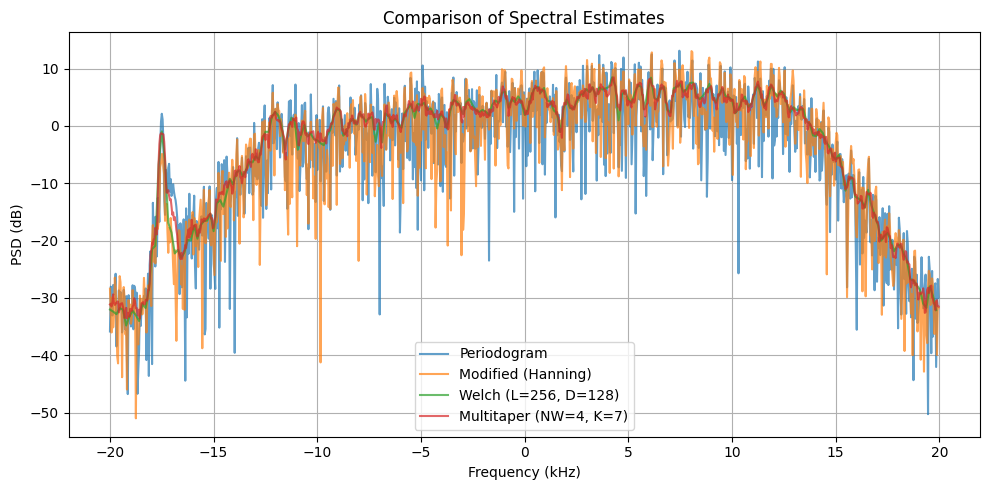

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(freq_shifted, 10*np.log10(periodogram_shifted), alpha=0.7, label='Periodogram')
ax.plot(freq_shifted, 10*np.log10(periodogram_windowed_shifted), alpha=0.7, label='Modified (Hanning)')
ax.plot(freq_welch, 10*np.log10(welch_psd_shifted), alpha=0.7, label='Welch (L=256, D=128)')
ax.plot(freq_shifted, 10*np.log10(multitaper_psd_shifted), alpha=0.7, label='Multitaper (NW=4, K=7)')
ax.set_xlabel('Frequency (kHz)')
ax.set_ylabel('PSD (dB)')
ax.set_title('Comparison of Spectral Estimates')
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

In [14]:
var_perio = periodogram_shifted**2
var_mod = periodogram_windowed_shifted**2
var_welch = welch_psd_shifted**2 / num_segments
var_mt = multitaper_psd_shifted**2 / K

print(f"{'Method':<25} {'Mean Var':>15}")
print("-"*42)
print(f"{'Periodogram':<25} {np.mean(var_perio):>15}")
print(f"{'Modified (Hanning)':<25} {np.mean(var_mod):>15}")
print(f"{'Welch (L=256, D=128)':<25} {np.mean(var_welch):>15}")
print(f"{'Multitaper (NW=4, K=7)':<25} {np.mean(var_mt):>15}")

Method                           Mean Var
------------------------------------------
Periodogram               9.186408996582031
Modified (Hanning)        11.16753881113607
Welch (L=256, D=128)      0.8061388153466875
Multitaper (NW=4, K=7)    0.751717483401958


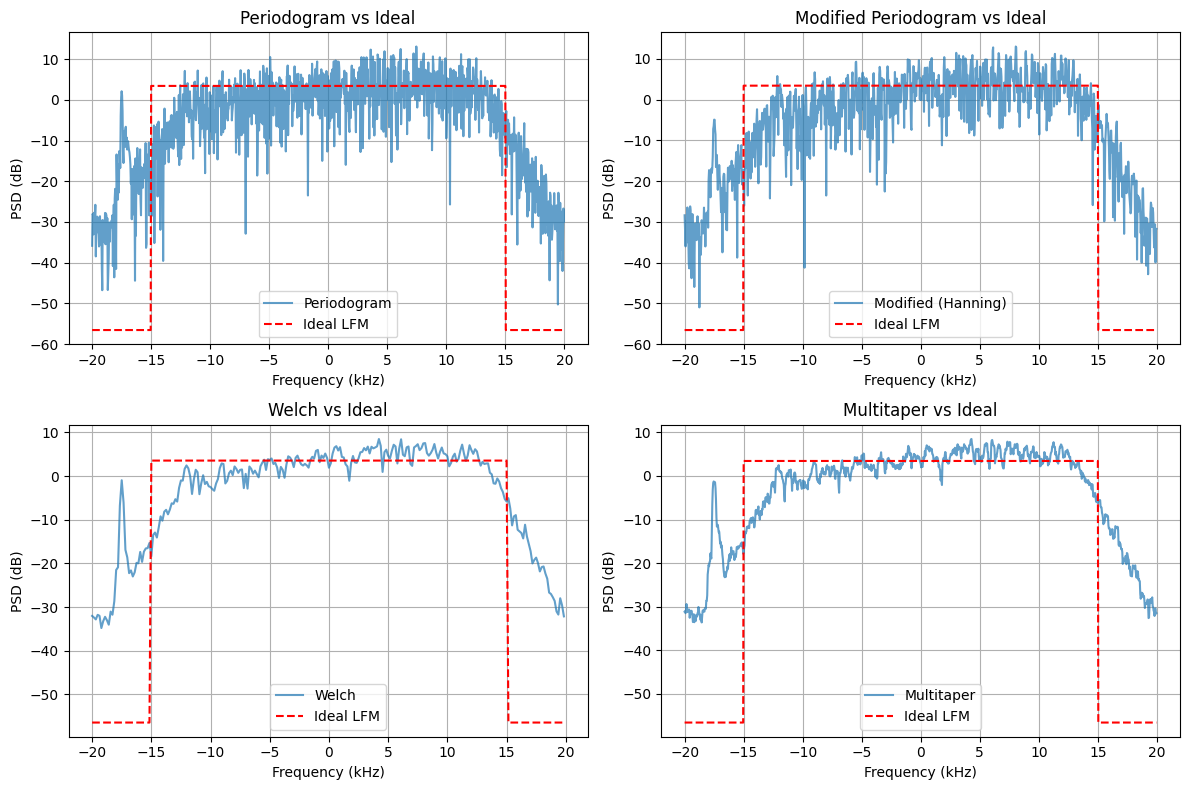

Method                     Mean Bias (dB)
------------------------------------------
Periodogram                       -3.8629
Modified (Hanning)                -3.3529
Welch (L=256, D=128)              -1.5703
Multitaper (NW=4, K=7)            -1.4260

Bandwidth estimation (6 dB drop from passband):
  Passband level: 3.45 dB
  -6 dB threshold: -2.55 dB
  Lower edge: -17.58 kHz
  Upper edge: 14.53 kHz
  Estimated bandwidth: 32.11 kHz (ideal: 30 kHz)


In [15]:
mask_N = np.abs(freq_shifted) <= (B/2/1000)
passband_lvl = np.mean(multitaper_psd_shifted[mask_N])
P_ideal_N = np.where(mask_N, passband_lvl, passband_lvl * 1e-6)

mask_L = np.abs(freq_welch) <= (B/2/1000)
passband_lvl_welch = np.mean(welch_psd_shifted[mask_L])
P_ideal_L = np.where(mask_L, passband_lvl_welch, passband_lvl_welch * 1e-6)

bias_perio = 10*np.log10(periodogram_shifted[mask_N]) - 10*np.log10(passband_lvl)
bias_mod = 10*np.log10(periodogram_windowed_shifted[mask_N]) - 10*np.log10(passband_lvl)
bias_welch = 10*np.log10(welch_psd_shifted[mask_L]) - 10*np.log10(passband_lvl_welch)
bias_mt = 10*np.log10(multitaper_psd_shifted[mask_N]) - 10*np.log10(passband_lvl)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].plot(freq_shifted, 10*np.log10(periodogram_shifted), alpha=0.7, label='Periodogram')
axes[0,0].plot(freq_shifted, 10*np.log10(P_ideal_N), 'r--', label='Ideal LFM')
axes[0,0].set_title('Periodogram vs Ideal')
axes[0,0].set_xlabel('Frequency (kHz)')
axes[0,0].set_ylabel('PSD (dB)')
axes[0,0].legend()
axes[0,0].grid()

axes[0,1].plot(freq_shifted, 10*np.log10(periodogram_windowed_shifted), alpha=0.7, label='Modified (Hanning)')
axes[0,1].plot(freq_shifted, 10*np.log10(P_ideal_N), 'r--', label='Ideal LFM')
axes[0,1].set_title('Modified Periodogram vs Ideal')
axes[0,1].set_xlabel('Frequency (kHz)')
axes[0,1].set_ylabel('PSD (dB)')
axes[0,1].legend()
axes[0,1].grid()

axes[1,0].plot(freq_welch, 10*np.log10(welch_psd_shifted), alpha=0.7, label='Welch')
axes[1,0].plot(freq_welch, 10*np.log10(P_ideal_L), 'r--', label='Ideal LFM')
axes[1,0].set_title('Welch vs Ideal')
axes[1,0].set_xlabel('Frequency (kHz)')
axes[1,0].set_ylabel('PSD (dB)')
axes[1,0].legend()
axes[1,0].grid()

axes[1,1].plot(freq_shifted, 10*np.log10(multitaper_psd_shifted), alpha=0.7, label='Multitaper')
axes[1,1].plot(freq_shifted, 10*np.log10(P_ideal_N), 'r--', label='Ideal LFM')
axes[1,1].set_title('Multitaper vs Ideal')
axes[1,1].set_xlabel('Frequency (kHz)')
axes[1,1].set_ylabel('PSD (dB)')
axes[1,1].legend()
axes[1,1].grid()

plt.tight_layout()
plt.show()

print(f"{'Method':<25} {'Mean Bias (dB)':>15}")
print("-"*42)
print(f"{'Periodogram':<25} {np.mean(bias_perio):>15.4f}")
print(f"{'Modified (Hanning)':<25} {np.mean(bias_mod):>15.4f}")
print(f"{'Welch (L=256, D=128)':<25} {np.mean(bias_welch):>15.4f}")
print(f"{'Multitaper (NW=4, K=7)':<25} {np.mean(bias_mt):>15.4f}")

psd_dB = 10*np.log10(multitaper_psd_shifted)
passband_dB = 10*np.log10(passband_lvl)
thresh = passband_dB - 6

above = psd_dB >= thresh
idx_above = np.where(above)[0]
f_low = freq_shifted[idx_above[0]]
f_high = freq_shifted[idx_above[-1]]
bw_est = f_high - f_low

print(f"\nBandwidth estimation (6 dB drop from passband):")
print(f"  Passband level: {passband_dB:.2f} dB")
print(f"  -6 dB threshold: {thresh:.2f} dB")
print(f"  Lower edge: {f_low:.2f} kHz")
print(f"  Upper edge: {f_high:.2f} kHz")
print(f"  Estimated bandwidth: {bw_est:.2f} kHz (ideal: {B/1000:.0f} kHz)")

### Results
1. Does the bias reduction help?
The boxcar periodogram is supposed to be unbiased, but this only holds for very large sample length. My periodogram is biased due to spectral leakage.

Method                     Mean Bias (dB)
Periodogram                       -3.8629
Modified (Hanning)                -3.3529
Welch (L=256, D=128)              -1.5703
Multitaper (NW=4, K=7)            -1.4260

2. Variance reduction helps

Method                           Mean Var
Periodogram               9.186408996582031
Modified (Hanning)        11.16753881113607
Welch (L=256, D=128)      0.8061388153466875
Multitaper (NW=4, K=7)    0.751717483401958

The transmitted (ideal) signal has a flat frequency response within the bandwidth of 30
kHz. There should be no signal outside the frequency band.

1. Estimate the true bandwidth (from guessing when the signal energy has dropped
below 6 dB from the passband)

I used the multitaper estimator to calculate the bandwidth estimation. I chose it since it had the best bias/variance tradeoff.

Bandwidth estimation (6 dB drop from passband):
  Passband level: 3.45 dB
  -6 dB threshold: -2.55 dB
  Lower edge: -17.58 kHz
  Upper edge: 14.53 kHz
  Estimated bandwidth: 32.11 kHz (ideal: 30 kHz)

2. What is wrong with the spectrum (compared to the ideal spectrum)
There is spectral leakage, so the passband apprears wider than it should be. This is expected due to finite sample length.
There is some tome at around -17kHz that is clearly not from our Tx that is skewing the frequency response. 

### Exercise 1 B
Create an array out of the following selection:
• Channel 9
• Start sample M = 7000
3
• Numberofsamples N = 2048
Assume that the sequence is WSS within the data window.
Calculate and plot the following spectral estimates:
• Theperiodogram
• Themodifiedperiodogram with a window of choice
• TheWelchmethodwith segment size L = 256 and overlap D = L/2
• Themultitaper spectral estimator using matlab’s function pmtm

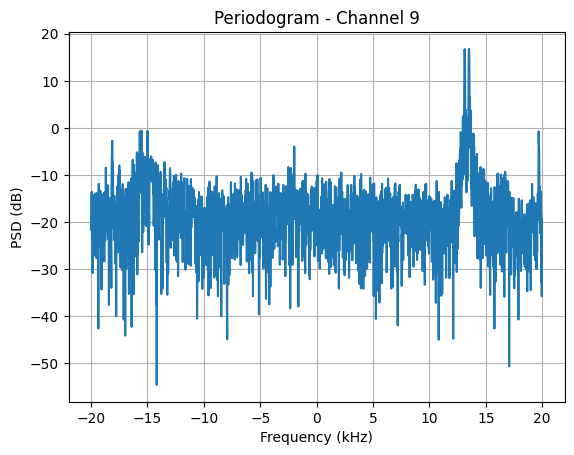

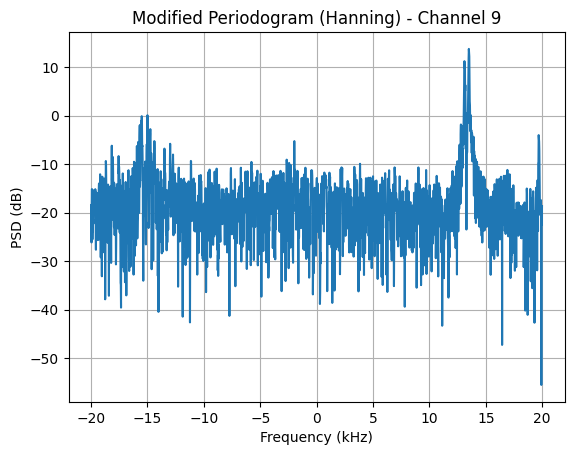

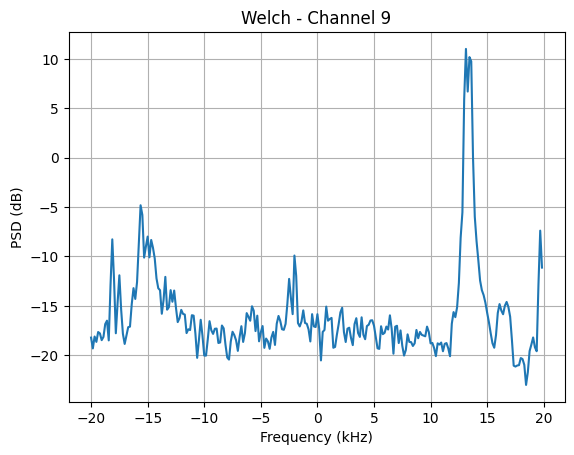

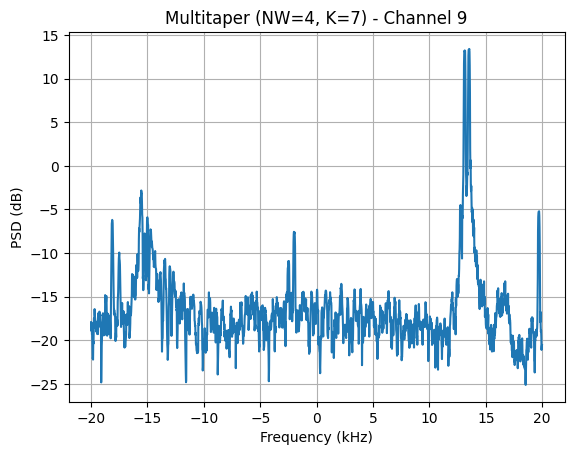

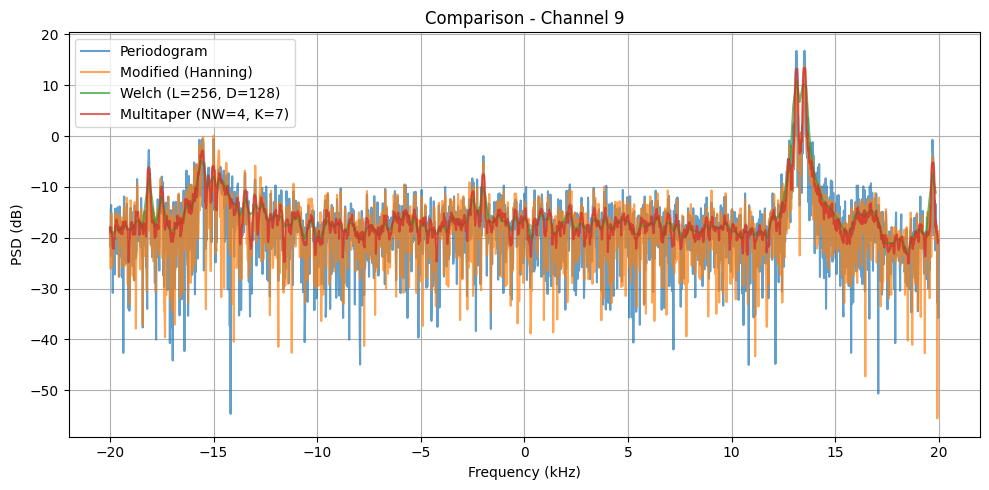

In [16]:
M_b = 7000
N_b = 2048
ch9 = X[M_b:M_b+N_b, 8]

freqs_b = np.fft.fftfreq(N_b, d=1/fs)
freq_shifted_b = np.fft.fftshift(freqs_b)/1000

# periodogram
fft_b = np.fft.fft(ch9)
perio_b = (1/(N_b*fs)) * np.abs(fft_b)**2
perio_b_shifted = np.fft.fftshift(perio_b)

plt.figure()
plt.plot(freq_shifted_b, 10*np.log10(perio_b_shifted))
plt.xlabel('Frequency (kHz)')
plt.ylabel('PSD (dB)')
plt.title('Periodogram - Channel 9')
plt.grid()
plt.show()

# modified periodogram (hanning)
win_b = np.hanning(N_b)
U_b = np.mean(win_b**2)
fft_win_b = np.fft.fft(ch9 * win_b)
mod_perio_b = (1/(N_b*fs*U_b)) * np.abs(fft_win_b)**2
mod_perio_b_shifted = np.fft.fftshift(mod_perio_b)

plt.figure()
plt.plot(freq_shifted_b, 10*np.log10(mod_perio_b_shifted))
plt.xlabel('Frequency (kHz)')
plt.ylabel('PSD (dB)')
plt.title('Modified Periodogram (Hanning) - Channel 9')
plt.grid()
plt.show()

# welch
L_b = 256
D_b = L_b//2
nseg_b = (N_b - D_b)//(L_b - D_b)
w_b = np.hanning(L_b)
Uw_b = np.mean(w_b**2)
freq_welch_b = np.fft.fftshift(np.fft.fftfreq(L_b, d=1/fs))/1000

welch_b = np.zeros(L_b)
for i in range(nseg_b):
    s = i*(L_b - D_b)
    seg = ch9[s:s+L_b] * w_b
    welch_b += (1/(L_b*fs*Uw_b)) * np.abs(np.fft.fft(seg))**2
welch_b /= nseg_b
welch_b_shifted = np.fft.fftshift(welch_b)

plt.figure()
plt.plot(freq_welch_b, 10*np.log10(welch_b_shifted))
plt.xlabel('Frequency (kHz)')
plt.ylabel('PSD (dB)')
plt.title('Welch - Channel 9')
plt.grid()
plt.show()

# multitaper
NW_b = 4
K_b = 2*NW_b - 1
taps_b, eigs_b = windows.dpss(N_b, NW_b, K_b, return_ratios=True)

mt_b = np.zeros(N_b)
for k in range(K_b):
    mt_b += (1/fs) * np.abs(np.fft.fft(ch9 * taps_b[k]))**2
mt_b /= K_b
mt_b_shifted = np.fft.fftshift(mt_b)

plt.figure()
plt.plot(freq_shifted_b, 10*np.log10(mt_b_shifted))
plt.xlabel('Frequency (kHz)')
plt.ylabel('PSD (dB)')
plt.title('Multitaper (NW=4, K=7) - Channel 9')
plt.grid()
plt.show()

# comparison plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(freq_shifted_b, 10*np.log10(perio_b_shifted), alpha=0.7, label='Periodogram')
ax.plot(freq_shifted_b, 10*np.log10(mod_perio_b_shifted), alpha=0.7, label='Modified (Hanning)')
ax.plot(freq_welch_b, 10*np.log10(welch_b_shifted), alpha=0.7, label='Welch (L=256, D=128)')
ax.plot(freq_shifted_b, 10*np.log10(mt_b_shifted), alpha=0.7, label='Multitaper (NW=4, K=7)')
ax.set_xlabel('Frequency (kHz)')
ax.set_ylabel('PSD (dB)')
ax.set_title('Comparison - Channel 9')
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

### Results
This part of the signal (M=7000) is dominated by additive noise and interference (tonal lines from other sources), not the transmitted LFM pulse.

1. **Does bias reduction help?**
Bias reduction does not help here. Since the signal is dominated by additive noise and interference rather than a wideband LFM pulse, there is no well-defined passband to preserve. The spectral leakage that bias reduction targets is not the limiting factor the spectrum is inherently narrowband tones in noise.

2. **Does variance reduction help?**
Variance reduction actually limits the spectral resolution in this case. At around 16–17 kHz there are two tones with similar frequencies. In the periodogram (high variance, high resolution), these tones are distinguishable as separate peaks. In the Welch estimates lower variance leads to lower resolution, the two tones merge and become harder to separate.

3. **What is the consequence of variance reduction?**
The consequence is a bias-variance-resolution tradeoff. Reducing variance smooths the spectrum, which merges closely spaced spectral features. For noise-dominated signals with narrowband interference, higher resolution (and thus higher variance) is preferred to resolve individual tones. The Welch method with L=256 segments has particularly coarse frequency resolution (Δf = fs/L ≈ 156 Hz), which is insufficient to separate tones that are close in frequency.

### Exercise 2 A
Create an array out of the following selection:
• Channel 14
• Start sample M = 400
• Numberofsamples N = 8192

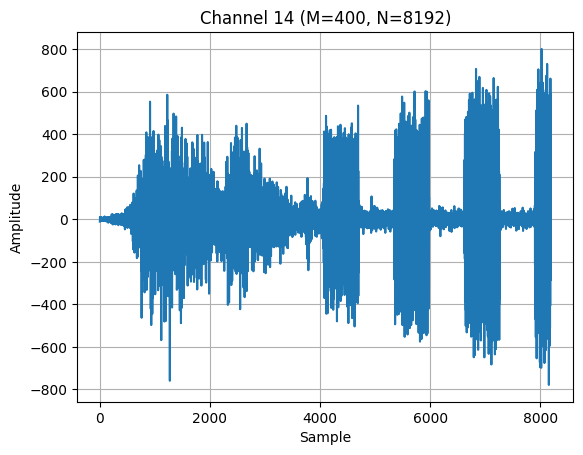

In [17]:
ch14_long = X[400:400+8192, 13]
plt.plot(ch14_long)
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.title('Channel 14 (M=400, N=8192)')
plt.grid()
plt.show()

This signal shows several different events with different amplitudes and durations in additive noise.

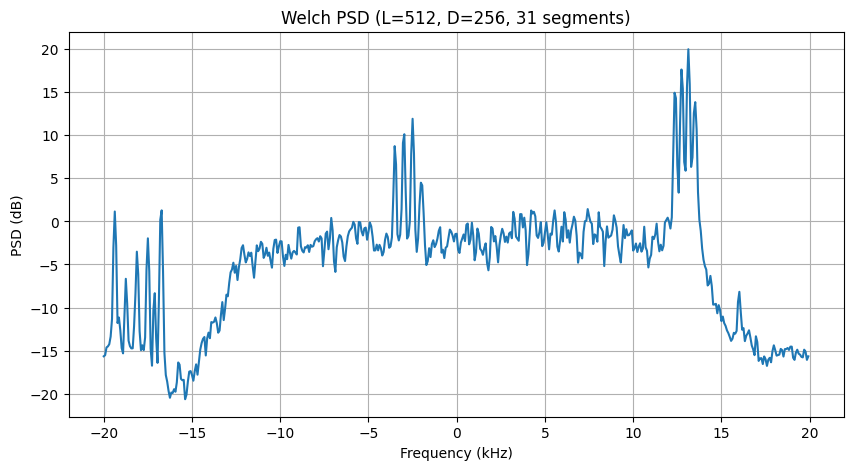

In [18]:
N_2a = len(ch14_long)
L_2a = 512
D_2a = L_2a//2
nseg_2a = (N_2a - D_2a)//(L_2a - D_2a)
w_2a = np.hanning(L_2a)
Uw_2a = np.mean(w_2a**2)
f_2a = np.fft.fftshift(np.fft.fftfreq(L_2a, d=1/fs))/1000

welch_2a = np.zeros(L_2a)
for i in range(nseg_2a):
    s = i*(L_2a - D_2a)
    seg = ch14_long[s:s+L_2a] * w_2a
    welch_2a += (1/(L_2a*fs*Uw_2a)) * np.abs(np.fft.fft(seg))**2
welch_2a /= nseg_2a
welch_2a_shifted = np.fft.fftshift(welch_2a)

plt.figure(figsize=(10, 5))
plt.plot(f_2a, 10*np.log10(welch_2a_shifted))
plt.xlabel('Frequency (kHz)')
plt.ylabel('PSD (dB)')
plt.title(f'Welch PSD (L={L_2a}, D={D_2a}, {nseg_2a} segments)')
plt.grid()
plt.show()

Here I see several tones. There are three clusters of tones that have similar frequencies. I also see the original LFM signal, but the tones are dominating the signal.

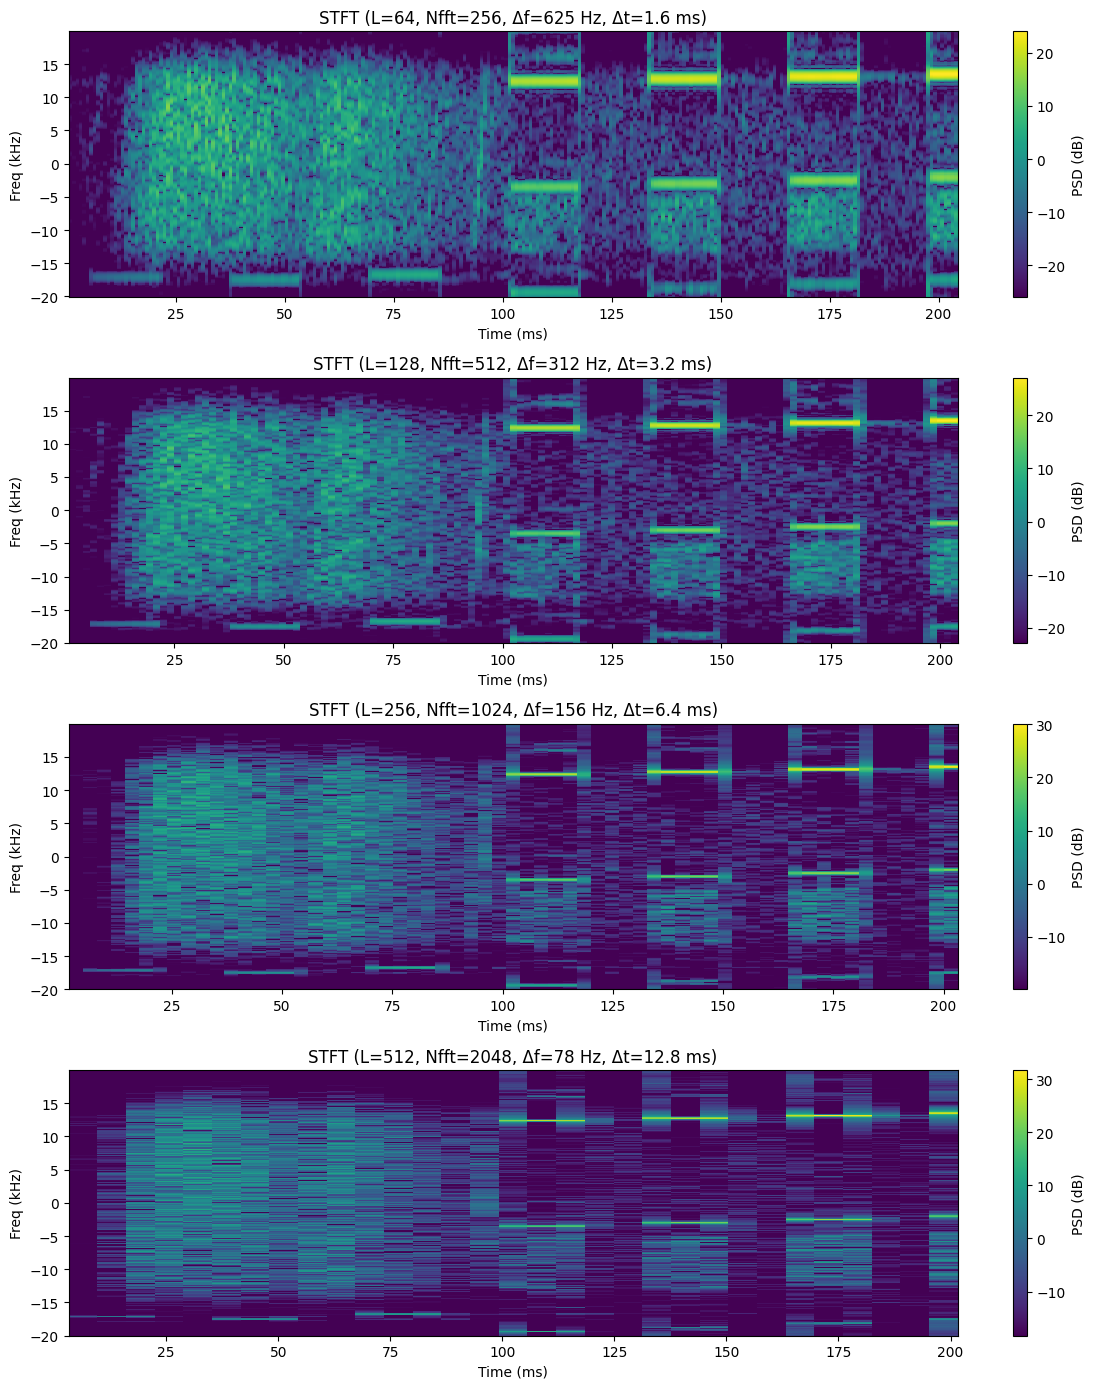

In [19]:
seg_lengths = [64, 128, 256, 512]
zp = 4
dyn_range = 50

fig, axes = plt.subplots(len(seg_lengths), 1, figsize=(12, 3.5*len(seg_lengths)))

for idx, Ls in enumerate(seg_lengths):
    Ds = Ls//2
    Nfft = Ls*zp
    w = np.hanning(Ls)
    Uw = np.mean(w**2)

    nseg = (N_2a - Ls)//Ds + 1
    stft = np.zeros((Nfft, nseg))
    t_c = np.zeros(nseg)

    for i in range(nseg):
        s = i*Ds
        seg = ch14_long[s:s+Ls] * w
        padded = np.zeros(Nfft, dtype=complex)
        padded[:Ls] = seg
        stft[:, i] = (1/(Ls*fs*Uw)) * np.abs(np.fft.fft(padded))**2
        t_c[i] = (s + Ls/2)/fs*1000

    f_stft = np.fft.fftshift(np.fft.fftfreq(Nfft, d=1/fs))/1000
    stft_s = np.fft.fftshift(stft, axes=0)
    stft_dB = 10*np.log10(stft_s + 1e-30)

    vmax = np.max(stft_dB)
    vmin = vmax - dyn_range

    im = axes[idx].pcolormesh(t_c, f_stft, stft_dB, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
    axes[idx].set_ylabel('Freq (kHz)')
    axes[idx].set_title(f'STFT (L={Ls}, Nfft={Nfft}, Δf={fs/Ls:.0f} Hz, Δt={Ls/fs*1000:.1f} ms)')
    axes[idx].set_xlabel('Time (ms)')
    fig.colorbar(im, ax=axes[idx], label='PSD (dB)')

plt.tight_layout()
plt.show()

1. What is the concequence of choosing segment length?
The segment length is proportional to the spectral resolution. Its basically a tradeoff between time or frequency resolution.

2. The chips seen in the time-frequency representation, especially from 100 ms to 200
ms, are from other interfering sensors. What is the length of the chips (in ms)? Are
the frequencies constant from chip to chip?

The chips are about 20ms in duration, and seem to have a slight frequency shift. The frequency shift could be due to doppler, hinting that the interferer is accelerating radially towards our sensor.

### Exercise 2 B
Create an array out of the following selection:
• Channel 32
• Start sample M = 400
• Numberofsamples N = 8192
Plot the real value of the signal as a timeseries.
Describe the characteristics of the signal by looking at the timeseries alone.
Plot the estimated power spectral density from the entire sequence using Welch’s method
from exercise 1A. Choose a suitable segment length, overlap and tapering.
Describe the characteristics of the signal by looking at the spectral estimate alone.
Use the code from exercise 2A and display the magnitude squared STFT as colorcoded
image in dB, with frequency in kHz on the y-axis and time in ms on the x-axis. Choose a
suitable segment length.

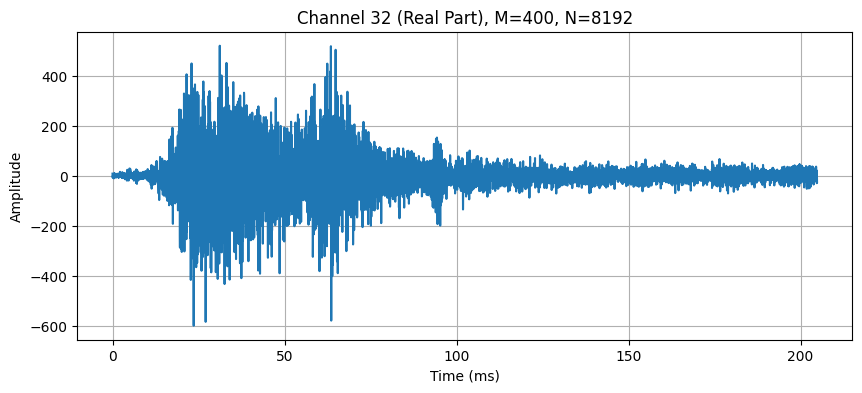

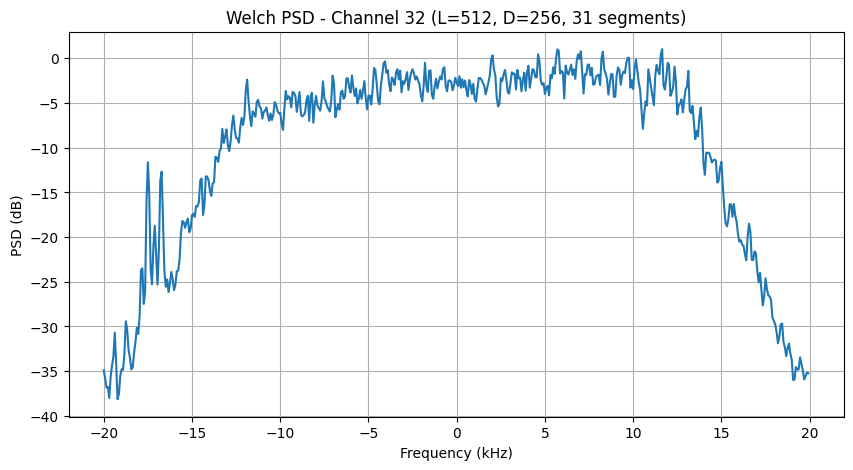

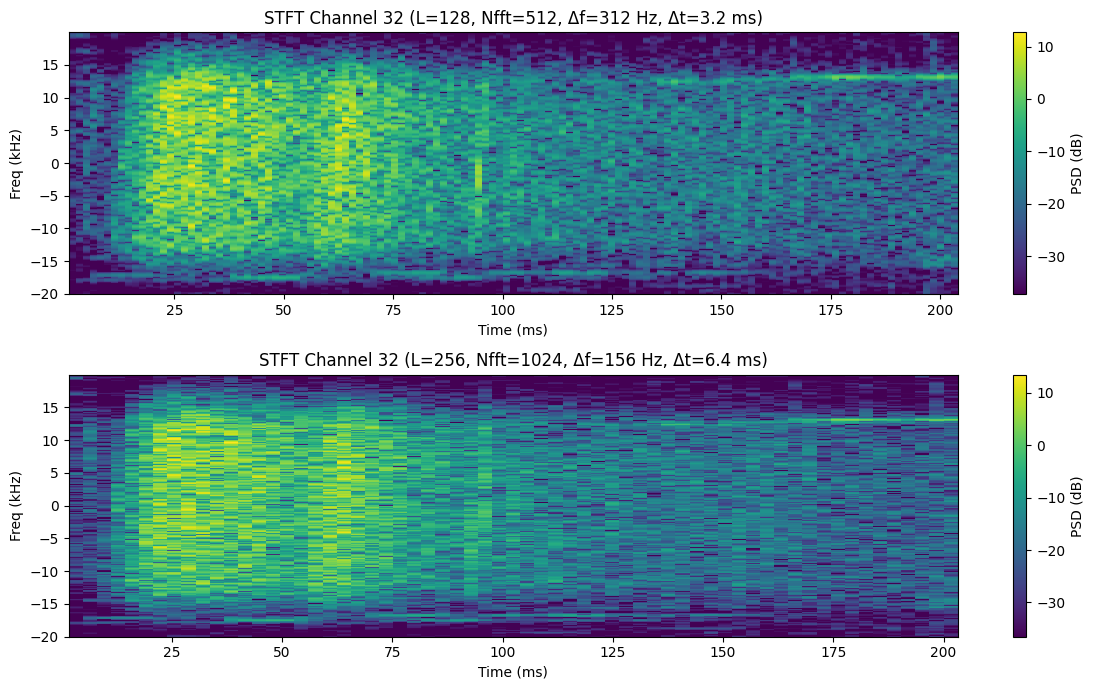

In [20]:
ch32 = X[400:400+8192, 31]

t_2b = np.arange(8192)/fs*1000
plt.figure(figsize=(10, 4))
plt.plot(t_2b, np.real(ch32))
plt.xlabel('Time (ms)')
plt.ylabel('Amplitude')
plt.title('Channel 32 (Real Part), M=400, N=8192')
plt.grid()
plt.show()

# welch
L_2b = 512
D_2b = L_2b//2
nseg_2b = (8192 - D_2b)//(L_2b - D_2b)
w_2b = np.hanning(L_2b)
Uw_2b = np.mean(w_2b**2)
f_2b = np.fft.fftshift(np.fft.fftfreq(L_2b, d=1/fs))/1000

welch_2b = np.zeros(L_2b)
for i in range(nseg_2b):
    s = i*(L_2b - D_2b)
    seg = ch32[s:s+L_2b] * w_2b
    welch_2b += (1/(L_2b*fs*Uw_2b)) * np.abs(np.fft.fft(seg))**2
welch_2b /= nseg_2b
welch_2b_shifted = np.fft.fftshift(welch_2b)

plt.figure(figsize=(10, 5))
plt.plot(f_2b, 10*np.log10(welch_2b_shifted))
plt.xlabel('Frequency (kHz)')
plt.ylabel('PSD (dB)')
plt.title(f'Welch PSD - Channel 32 (L={L_2b}, D={D_2b}, {nseg_2b} segments)')
plt.grid()
plt.show()

# stft
seg_lens_2b = [128, 256]
zp = 4
dyn_range = 50

fig, axes = plt.subplots(len(seg_lens_2b), 1, figsize=(12, 3.5*len(seg_lens_2b)))

for idx, Ls in enumerate(seg_lens_2b):
    Ds = Ls//2
    Nfft = Ls*zp
    w = np.hanning(Ls)
    Uw = np.mean(w**2)

    nseg = (8192 - Ls)//Ds + 1
    stft = np.zeros((Nfft, nseg))
    t_c = np.zeros(nseg)

    for i in range(nseg):
        s = i*Ds
        seg = ch32[s:s+Ls] * w
        padded = np.zeros(Nfft, dtype=complex)
        padded[:Ls] = seg
        stft[:, i] = (1/(Ls*fs*Uw)) * np.abs(np.fft.fft(padded))**2
        t_c[i] = (s + Ls/2)/fs*1000

    f_stft = np.fft.fftshift(np.fft.fftfreq(Nfft, d=1/fs))/1000
    stft_s = np.fft.fftshift(stft, axes=0)
    stft_dB = 10*np.log10(stft_s + 1e-30)

    vmax = np.max(stft_dB)
    vmin = vmax - dyn_range

    im = axes[idx].pcolormesh(t_c, f_stft, stft_dB, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
    axes[idx].set_ylabel('Freq (kHz)')
    axes[idx].set_title(f'STFT Channel 32 (L={Ls}, Nfft={Nfft}, Δf={fs/Ls:.0f} Hz, Δt={Ls/fs*1000:.1f} ms)')
    axes[idx].set_xlabel('Time (ms)')
    fig.colorbar(im, ax=axes[idx], label='PSD (dB)')

plt.tight_layout()
plt.show()

Describe the characteristics of the signal by looking at the spectral estimate alone.

The spectogram appears to be a LFM signal with some spectral leakage, plus some interfering tones at about -17kHz. 

Describe the characteristics of the signal based on the STFT.

The signal appears to be spread equaly in frequency domain from about 15 to -15 kHz. The LFM starts at aroud 20ms and the PSD fades slowly thereafter. There is also an interfering tone at about 15kHz starting around 130ms. The -17kHz interferer is less obvious in the STFT visualzation.

What is the difference between the data in channel 14 and 32?

The difference is that channel 32 has much less interference from other tones. The interferers do not dominate the signal like they do in channel 14. It is strange that such noise would only appear strongly on channel 14 and barely on channel 32. My guess would be that this interference is caused by faulty electronics, not something in the farfield.